# Explanation of the routines in SYK_fft.py

*SYK_fft is written by Aravindh Shankar.*

*Explanation by Koenraad Schalm. Oct 2024*

In [5]:
from SYK_fft import *
import numpy as np
import matplotlib.pyplot as plt

/Users/kschalm/Dropbox/Computing/SYK Wormhole/TwoSidedYSYK-main-Aravindh/Benchmarking


SYK_fft.py loads some specific variations on the FFT routines that are useful.

Specifically, whereas the standard FFT is directly applicable to a discretized function based on the left-point rule, i.e. the value assigned to the interval $[f(t),f(t+\Delta t)]$ is $f(t)$, the routine here uses the midpoint rule: the value assigned to the interval $[f(t),f(t+\Delta t)]$ is $f(t+\frac{1}{2}\Delta t)$.

Secondly it immediately reshifts the frequency output to be centered around $\omega=0$. In contrast the standard FFT transform computes the frequencies $\omega =0,1, N-1$. 

It does so in four commands: for bosonic functions, i.e. strictly periodic functions it has the commands `Time2FreqB` and its inverse `Freq2TimeB`; for fermionic, i.e. strictly antiperiodic functions it has the commands 
`Time2FreqF` and its inverse `Freq2TimeF`.

### Bosonic periodic functions

The command `Time2FreqB` gives
```
return (beta)*np.exp(1j*np.pi*n/Nbig)*ifft(np.exp(-1j*np.pi*(n + 1./2))*gg)
```
Thus it computes
$$
\begin{align}
\hat{F}[m] &= F(2\pi m/\beta) = \beta e^{i\pi m/N} \frac{1}{N}\sum_{n=0}^{N-1} e^{-i \pi (n+1/2)} f(n\Delta t) e^{2\pi imn/N}\\
& = \beta e^{i\pi m/N} \frac{1}{N}\sum_{n=0}^{N-1} e^{-i \pi/2} f(n\Delta t) e^{2\pi i(m-N/2)n/N}\\
& = \beta e^{i\pi (m-N/2)/N}\frac{1}{N}\sum_{n=0}^{N-1} f(n\Delta t) e^{2\pi i(m-N/2)n/N}\\
\end{align}
$$
The remaining phase is there to account for the midpoint rule 
$$
\begin{align}
\hat{F}[m]
& = \frac{\beta}{N} \sum_{n=0}^{N-1} f(n\Delta t) e^{2\pi i(m-N/2)(n+\frac{1}{2})/N}\\
\end{align}
$$
So if $f(n\Delta t)$ is actually $f((n+1/2)\Delta t)$ this is the discrete Fourier transform of the midpoint rule for the Fourier integral approximated with a Riemann sum.
$$
\int_0^\beta dt f(t) = \sum_{n=0}^{N-1}\Delta t f((n+\frac{1}{2})\Delta t) ~~~\text{with}~~~\Delta t = \frac{\beta}{N}
$$

Secondly, we see that it immediately maps the output to an array frequencies ranging from $-N/2$ to $N/2-1$.
(Recall numpy-arrays start counting at 0).

**Warning** Note that the frequencies are not periodic. If one shift $m \rightarrow m+N$ then $\hat{F}[m+N] = \frac{\beta}{N} \sum_{n=0}^{N-1} f(n\Delta t) e^{2\pi i(m-N/2)(n+\frac{1}{2})/N}e^{2\pi i (n+\frac{1}{2})}$. 



In [126]:
Ntest = 32
ntest = np.arange(Ntest)
beta = 5000

Gtest = -np.ones(Ntest)
Gfreqtest = Time2FreqB(Gtest,Ntest,beta)
#ntest = np.arange(32)
#Ntest = 32
Gfreqcomp1 = beta*ifft(Gtest)
Gfreqcomp2 = beta *np.exp(1j*np.pi*ntest/Ntest)*ifft(np.exp(-1j*np.pi*(ntest+1./2))*Gtest)
Gfreqcomp3 = np.fft.fftshift(Gfreqcomp1)
# (beta)*np.exp(1j*np.pi*n/Nbig)*ifft(np.exp(-1j*np.pi*(n + 1./2))*gg) 

In [129]:
print(Gfreqtest)
print(Gfreqcomp1)
print(Gfreqcomp2)
print(Gfreqcomp3)
print(Gfreqcomp3-Gfreqcomp2)

[ 1.13882897e-12+0.00000000e+00j -2.83268680e-12+4.11007363e-12j
  9.60440437e-13+3.21909633e-13j -3.12391381e-13-7.23677474e-13j
  5.87815118e-13+2.30655762e-13j  7.19181437e-13-2.02464175e-13j
  7.70119254e-13-3.25324248e-13j -6.92505572e-13-2.37149592e-12j
 -4.47356091e-12-1.96261557e-13j -1.42633054e-12+4.03898107e-12j
  2.15487251e-12+1.21881512e-12j -4.18234975e-14+1.62216284e-13j
  9.06255066e-13+2.00742855e-12j  1.68325074e-12+2.69289016e-13j
  5.66310564e-13+7.84948378e-13j  3.60310190e-12+1.22073400e-12j
 -5.00000000e+03-9.76856845e-12j -3.60310190e-12+1.22073400e-12j
 -5.66310564e-13+7.84948378e-13j -1.68325074e-12+2.69289016e-13j
 -9.06255066e-13+2.00742855e-12j  4.18234975e-14+1.62216284e-13j
 -2.15487251e-12+1.21881512e-12j  1.42633054e-12+4.03898107e-12j
  4.47356091e-12-1.96261557e-13j  6.92505572e-13-2.37149592e-12j
 -7.70119254e-13-3.25324248e-13j -7.19181437e-13-2.02464175e-13j
 -5.87815118e-13+2.30655762e-13j  3.12391381e-13-7.23677474e-13j
 -9.60440437e-13+3.219096

The inverse command `Freq2TimeB` gives
```

return 1./beta *np.exp(1j*np.pi*(n+1./2))*fft(np.exp(-1j*np.pi*n/Nbig)*gg)

```
Thus it computes
$$
\begin{align}
f[m] &= \frac{1}{\beta} e^{i\pi(m+1/2)}\sum_{n=0}^{N-1}e^{-i\pi n/N} F(2\pi n/\beta) e^{-i 2 \pi m n/N}\\
&=\frac{1}{\beta} e^{i\pi(m+1/2)}\sum_{n=0}^{N-1} F(2\pi n/\beta) e^{-i 2 \pi (m+1/2) n/N} \\
\end{align}
$$
This is again the midpoint value $f((m+1/2)\Delta t)$ as it should be.

The phase is there to make the compensate between zero-center-valued frequencies and the `fft`-definition which start the array at zero frequency
$$
\begin{align}
f[m] &=\frac{1}{\beta} e^{i\pi(m+1/2)}\sum_{n=-N/2}^{N/2-1} F(2\pi n/\beta) e^{-i2\pi(m+1/2) (n+\frac{N}{2})/N}\\
&=\frac{1}{\beta} e^{i\pi(m+1/2)}e^{-i2\pi(m+1/2)\frac{N}{2N}}\sum_{n=-N/2}^{N/2-1} F(2\pi n/\beta) e^{-i2\pi(m+1/2)n/N}\\ 
& =\frac{1}{\beta}\sum_{n=-N/2}^{N/2-1} F(2\pi n/\beta) e^{-i2\pi(m+1/2)n/N}
\end{align}
$$

One can check the inverses for completeness
$$
\begin{align}
f[m] & =\frac{1}{\beta}\sum_{n=-N/2}^{N/2-1} F(2\pi n/\beta) e^{-i 2 \pi (m+1/2) n/N} \\
& = \frac{1}{\beta} \sum_{n=-N/2}^{N/2-1} \left(\frac{\beta}{N} \sum_{p=0}^{N-1} f(p\Delta t) e^{2\pi i(n)(p+\frac{1}{2})/N} \right)e^{-i 2 \pi (m+1/2) n/N}
\end{align}
$$
**Note that to sum over the correct range the argument is $e^{2\pi i(n)(p+\frac{1}{2})/N}$ and not $e^{2\pi i(n-N/2)(p+\frac{1}{2})/N}$. The shift is already taken into account in the range of the sum**
$$
\begin{align}
f[m]
&=\frac{1}{N}\sum_{p=0}^{N-1} \sum_{n=-N/2}^{N/2-1} f(p\Delta t) e^{2\pi i n(p-m)/N}\\
&=\frac{1}{N}\sum_{p=0}^{N-1} \sum_{n=0}^{N-1} f(p\Delta t) e^{2\pi i (n-N/2)(p-m)/N}\\
&=\frac{1}{N}\sum_{p=0}^{N-1} \sum_{n=0}^{N-1} f(p\Delta t) e^{2\pi i n(p-m)/N}\\
& = f(m\Delta t) 
\end{align}
$$
This can be confirmed from the primary definitions:
$$
\begin{align}
f[m] &= \frac{1}{\beta} e^{i\pi(m+1/2)}\sum_{n=0}^{N-1}e^{-i\pi n/N} F(2\pi n/\beta) e^{-i 2 \pi m n/N}\\
& = \frac{1}{\beta} e^{i\pi(m+1/2)}\sum_{n=0}^{N-1}e^{-i\pi n/N}\left(\beta e^{i\pi n/N} \frac{1}{N}\sum_{p=0}^{N-1} e^{-i \pi (p+1/2)} f(p\Delta t) e^{2\pi inp/N} \right) e^{-i 2 \pi m n/N}\\
& = e^{i\pi(m+1/2)}\frac{1}{N}\sum_{p,n} f(p\Delta t) e^{-i \pi (p+1/2)}   e^{2\pi i n(p-m)/N}\\
&= f(p\Delta t)
\end{align}
$$

In [148]:
Gtimetestfreq=Freq2TimeB(Gfreqtest,Ntest,beta)
print(Gtimetestfreq)

[-1.+5.30015921e-31j -1.+6.90253292e-31j -1.+6.90253292e-31j
 -1.-4.93038066e-32j -1.+1.38050658e-30j -1.-7.88860905e-31j
 -1.+1.97215226e-31j -1.+3.94430453e-31j -1.+6.90253292e-31j
 -1.-3.94430453e-31j -1.+1.97215226e-31j -1.+1.18329136e-30j
 -1.+1.13398755e-30j -1.-3.94430453e-31j -1.-6.55779146e-32j
 -1.+7.88860905e-31j -1.+6.90253292e-31j -1.+0.00000000e+00j
 -1.+9.86076132e-32j -1.+0.00000000e+00j -1.+0.00000000e+00j
 -1.-7.88860905e-31j -1.+1.38050658e-30j -1.+1.18329136e-30j
 -1.+0.00000000e+00j -1.+0.00000000e+00j -1.+1.18329136e-30j
 -1.-3.94430453e-31j -1.+0.00000000e+00j -1.+0.00000000e+00j
 -1.+7.88860905e-31j -1.-3.94430453e-31j]


### Fermionic antiperiodic functions

Now the fermions: The command `Time2FreqF` reads
```
return (beta)*np.exp(1j*np.pi*n/Nbig)*ifft(np.exp(-1j*np.pi*(Nbig-1)*(n+1./2)/Nbig)*gg)
```
It thus computes 
$$
\begin{align}
F((2n+1)\pi/\beta) &= \beta e^{i\pi n/N} \frac{1}{N}\sum_{m=0}^{N-1} e^{-i\pi(N-1)(m+1/2)/N} f(m\Delta t) e^{2\pi i mn/N}\\
&=  \frac{\beta}{N}\sum_{m=0}^{N-1} e^{-i\pi(N-1)(m+1/2)/N} f(m\Delta t) e^{2\pi i (m+\frac{1}{2})n/N}\\
&=  \frac{\beta}{N}\sum_{m=0}^{N-1} f(m\Delta t) e^{2\pi i (m+\frac{1}{2})(n-\frac{N-1}{2})/N}
\end{align}
$$
This is therefore again the midpoint rule in time, and it computes precisely the odd frequencies
$$
\omega =\{-\frac{N-1}{2},-\frac{N-1}{2}+1,-\frac{N-1}{2}+2,\ldots,-\frac{N-1}{2}+N-1\}\frac{2\pi n}{\beta} = \{-N+1,-N+3,-N+5,\ldots,N-1\}\frac{\pi}{\beta} 
$$
The fact that we only compute odd frequencies _seems_ to indicate that we are accounting for the fact that the fermionic Green's functions are anti-periodic correctly. This is a bit more subtle, however. We comment below.
First:

The inverse function `Freq2TimeF` is given by
```
return 1./beta *np.exp(1j*np.pi*(Nbig-1)*(2*n+1)/(2*Nbig))*fft(np.exp(-1j*np.pi*n/Nbig)*gg)
```
It therefore computes 
$$
\begin{align}
f(m) & = \frac{1}{\beta} e^{i\pi(N-1)(m+\frac{1}{2})/N} \sum_{n=0}^{N-1} e^{-i\pi n/N}F((2n+1)\pi/\beta)e^{-2\pi i mn/N}
\end{align}
$$
It clearly is the inverse
$$
\begin{align}
f(m) & = \frac{1}{\beta} e^{i\pi(N-1)(m+\frac{1}{2})/N} \sum_{n=0}^{N-1} e^{-i\pi n/N}\left(\beta e^{i\pi n/N} \frac{1}{N}\sum_{p=0}^{N-1} e^{-i\pi(N-1)(p+1/2)/N} f(p\Delta t) e^{2\pi i pn/N}\right)e^{-2\pi i mn/N}
\\
& = \frac{1}{N}e^{i\pi(N-1)(m+\frac{1}{2})/N}\sum_{p=0}^{N-1}\sum_{n=0}^{N-1}e^{-i\pi(N-1)(p+1/2)/N}f(p\Delta t) e^{2\pi in(p-m)/N}\\
& = f(m\Delta t)
\end{align}
$$

Now in the discretized Fourier transform a closer inspection seems to reveal that we used that $f(t)$ was periodic.
For fermions this is not true. They are anti-periodic.
The solution is the following.
**[What is the solution]**

Q = 0.00+0.00j


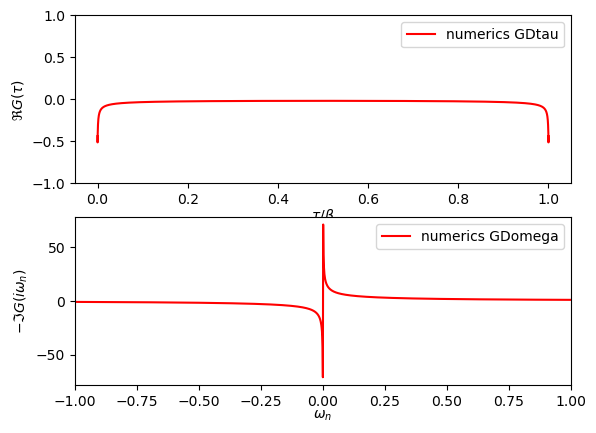

In [22]:
fig, (ax1,ax2) = plt.subplots(2)
print(f'Q = {Q:.2f}')

ax1.plot(tau/beta, np.real(GDtau), 'r', label = 'numerics GDtau')
ax1.set_ylim(-1,1)
ax1.set_xlabel(r'$\tau/\beta$',labelpad = 0)
ax1.set_ylabel(r'$\Re{G(\tau)}$')
ax1.legend()

ax2.plot(omega,-np.imag(GDomega), 'r', label = 'numerics GDomega')
ax2.set_xlim(-1,1)
ax2.set_xlabel(r'$\omega_n$', labelpad=0)
ax2.set_ylabel(r'$-\Im{G(i\omega_n)}$')
ax2.legend()